### Install required packages

This cell installs the main Python packages used in the notebook, such as Biopython and pandas. It prepares the environment so the sequence-processing and table-generation cells can run correctly.

In [ ]:
# Install the packages needed for this notebook
import sys
!{sys.executable} -m pip install biopython pandas

### Load or fetch sequence data

This cell defines the helper functions used to either upload a local FASTA file or fetch protein sequences from NCBI. At the end, it runs the input workflow and stores both the sequence table and the original records for later export.

In [ ]:
from Bio import SeqIO, Entrez
from io import StringIO
import pandas as pd
import re

# Here you can add your email, so in case of any issues,
# NCBI can contact you regarding the request.
Entrez.email = "your_email@example.com"


# Convert sequence records into a clean DataFrame
def df_from_records(records):
    df = pd.DataFrame([{
        "ID": r.id,
        "Description": r.description,
        "Sequence": str(r.seq),
        "Length": len(r.seq)
    } for r in records])

    df = df.drop_duplicates(subset="Sequence").reset_index(drop=True)
    return df


def norm(x):
    return re.sub(r"\s+", " ", x.strip().lower())


def ask_menu(prompt, options):
    while True:
        print("\n" + prompt)
        for i, op in enumerate(options, 1):
            print(f"{i}. {op}")

        x = input(f"Enter choice (1-{len(options)}): ").strip()

        if x.isdigit() and 1 <= int(x) <= len(options):
            return int(x) - 1

        print("Invalid choice. Please try again.")


def ask_positive_int(prompt):
    while True:
        x = input(prompt).strip()

        if x.isdigit() and int(x) > 0:
            return int(x)

        print("Please enter a whole number greater than 0.")


def ask_nonempty(prompt):
    while True:
        x = input(prompt).strip()

        if x:
            return x

        print("Input cannot be empty.")


# ------------------------------------------------------------
# FASTA upload option
# ------------------------------------------------------------

def load_fasta():
    """
    Upload one or more FASTA files directly into Google Colab.
    This follows the same useful structure as the Fly-By-Denial notebook:
    uploaded files are parsed into one master list called all_fasta_sequences.
    """
    global all_fasta_sequences

    all_fasta_sequences = []

    try:
        from google.colab import files

        print("Please select your FASTA file(s) for upload:")
        uploaded = files.upload()

        if len(uploaded) == 0:
            raise ValueError("No file was uploaded.")

        print("\n--- Processing uploaded FASTA files ---")

        for filename in uploaded.keys():
            print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

            with open(filename, "wb") as f:
                f.write(uploaded[filename])

            try:
                sequences_from_file = list(SeqIO.parse(filename, "fasta"))
                print(f"Loaded {len(sequences_from_file)} sequences from {filename}")

                all_fasta_sequences.extend(sequences_from_file)

                for i, seq_record in enumerate(sequences_from_file[:3]):
                    print(f"  Sample from {filename}: ID: {seq_record.id}, Length: {len(seq_record.seq)}")
                    if len(seq_record.seq) > 50:
                        print(f"  Sequence preview: {str(seq_record.seq)[:50]}...\n")
                    else:
                        print(f"  Sequence preview: {str(seq_record.seq)}\n")

            except Exception as e:
                print(f"Error reading FASTA file {filename}: {e}")

        print(f"Total sequences loaded from all uploaded FASTA files: {len(all_fasta_sequences)} SeqRecords.")

        if len(all_fasta_sequences) == 0:
            raise ValueError("No sequences were found in the uploaded FASTA file(s).")

        return all_fasta_sequences

    except ImportError:
        print("\nGoogle Colab upload was not detected.")
        print("You may be running this notebook locally.")

        while True:
            path = ask_nonempty("Please enter the full path of your FASTA file: ")

            try:
                sequences_from_file = list(SeqIO.parse(path, "fasta"))

                if sequences_from_file:
                    all_fasta_sequences.extend(sequences_from_file)
                    print(f"Loaded {len(all_fasta_sequences)} sequences from {path}")
                    return all_fasta_sequences

                print("No sequences were found in that FASTA file.")

            except Exception as e:
                print(f"Could not read FASTA file: {e}")


# ------------------------------------------------------------
# NCBI guided search section
# ------------------------------------------------------------

ORG_HINTS = {
    "h1n1": "Influenza A virus",
    "influenza h1n1": "Influenza A virus",
    "flu h1n1": "Influenza A virus",
    "swine flu": "Influenza A virus",
    "covid": "Severe acute respiratory syndrome coronavirus 2",
    "covid 19": "Severe acute respiratory syndrome coronavirus 2",
    "covid-19": "Severe acute respiratory syndrome coronavirus 2",
    "sars cov 2": "Severe acute respiratory syndrome coronavirus 2",
    "sars-cov-2": "Severe acute respiratory syndrome coronavirus 2",
    "tb": "Mycobacterium tuberculosis",
    "e coli": "Escherichia coli",
    "mrsa": "Staphylococcus aureus",
}

GROUPS = {
    "Bacteria": {
        "examples": ["Escherichia coli", "Bacillus subtilis", "Mycobacterium tuberculosis"],
        "proteins": ["dnaK", "gyrA", "rpoB"],
        "nucleotide_markers": ["16S ribosomal RNA"]
    },
    "Archaea": {
        "examples": ["Methanococcus maripaludis", "Methanosarcina barkeri", "Methanocaldococcus jannaschii"],
        "proteins": ["mcrA", "mcrB", "mcrG"],
        "nucleotide_markers": ["16S ribosomal RNA"]
    },
    "Viruses": {
        "examples": ["Influenza A virus", "Severe acute respiratory syndrome coronavirus 2", "Human immunodeficiency virus 1"],
        "proteins_by_organism": {
            "Influenza A virus": ["matrix protein 2", "hemagglutinin", "neuraminidase", "nucleoprotein"],
            "Severe acute respiratory syndrome coronavirus 2": ["spike", "nucleocapsid", "membrane"],
            "Human immunodeficiency virus 1": ["env", "gag", "pol", "reverse transcriptase", "integrase"]
        }
    },
    "Fungi": {
        "examples": ["Saccharomyces cerevisiae", "Candida albicans", "Aspergillus fumigatus"],
        "proteins": ["beta-tubulin", "actin", "calmodulin"],
        "nucleotide_markers": ["18S ribosomal RNA"]
    },
    "Protozoa": {
        "examples": ["Plasmodium falciparum", "Trypanosoma brucei", "Giardia lamblia"],
        "proteins": ["actin", "tubulin"],
        "nucleotide_markers": ["18S ribosomal RNA"]
    }
}


def suggest_organism(text):
    t = norm(text)

    if t in ORG_HINTS:
        return ORG_HINTS[t]

    if t in {"virus", "viruses", "bacteria", "archaea", "fungi", "protozoa", "microbe", "microbes"}:
        return None

    return text.strip()


def ask_exact_or_group():
    mode = ask_menu("How do you want to choose the microorganism?", [
        "I know the exact microorganism name",
        "Let me choose from groups"
    ])

    if mode == 0:
        while True:
            org = ask_nonempty("Enter microorganism name: ")
            s = suggest_organism(org)

            if s is None:
                print("That is too broad. Please enter a specific organism name or use group selection.")
                continue

            if s != org.strip():
                print(f"\nThat input is not the best exact organism name.")
                print(f"Did you mean: {s}")

                c = ask_menu("Choose one:", ["Yes, use this", "No, enter again", "Switch to group selection"])

                if c == 0:
                    return s, None

                if c == 1:
                    continue

                return ask_group_mode()

            return org.strip(), None

    return ask_group_mode()


def ask_group_mode():
    group_names = list(GROUPS.keys())
    group = group_names[ask_menu("Choose microorganism group:", group_names)]
    ex = GROUPS[group]["examples"]

    choice = ask_menu(f"Choose an example organism from {group}, or type your own:", ex + ["Type my own organism name"])

    if choice < len(ex):
        return ex[choice], group

    while True:
        org = ask_nonempty("Enter microorganism name: ")
        s = suggest_organism(org)

        if s is None:
            print("That is too broad for an exact organism name.")
            continue

        if s != org.strip():
            print(f"\nDid you mean: {s}")

            c = ask_menu("Choose one:", ["Yes, use this", "No, enter again"])

            if c == 0:
                return s, group

            continue

        return org.strip(), group


def ask_protein(group, organism):
    mode = ask_menu("How do you want to choose the protein/gene?", [
        "Type the exact protein/gene name",
        "Choose from suggested options"
    ])

    if group == "Viruses":
        suggestions = GROUPS[group]["proteins_by_organism"].get(
            organism,
            ["matrix protein 2", "spike", "nucleocapsid", "hemagglutinin", "neuraminidase", "env", "gag", "pol"]
        )
    elif group:
        suggestions = GROUPS[group]["proteins"]
    else:
        suggestions = ["mcrA", "dnaK", "gyrA", "rpoB", "matrix protein 2", "spike"]

    if mode == 1:
        return suggestions[ask_menu("Choose a protein/gene:", suggestions)]

    while True:
        p = ask_nonempty("Enter protein/gene name: ")
        t = norm(p)

        if t in {"h1n1", "influenza h1n1", "flu", "virus"}:
            print("\nThat is not a protein/gene name.")
            print("For Influenza A virus, try one of these:")

            flu_ops = ["matrix protein 2", "hemagglutinin", "neuraminidase", "nucleoprotein"]
            return flu_ops[ask_menu("Choose one:", flu_ops)]

        return p.strip()


def build_query(org, protein):
    return f'"{protein}" AND "{org}"[Organism]'


def fetch_ncbi(query, n):
    h = Entrez.esearch(db="protein", term=query, retmax=n)
    res = Entrez.read(h)
    h.close()

    ids = res.get("IdList", [])

    if not ids:
        return []

    h = Entrez.efetch(db="protein", id=",".join(ids), rettype="fasta", retmode="text")
    fasta = h.read()
    h.close()

    records = list(SeqIO.parse(StringIO(fasta), "fasta"))

    unique_records = []
    seen_sequences = set()

    for r in records:
        seq = str(r.seq)

        if seq not in seen_sequences:
            seen_sequences.add(seq)
            unique_records.append(r)

    return unique_records


def guided_ncbi():
    global all_fasta_sequences

    while True:
        level = ask_menu("Choose search mode:", ["Beginner", "Advanced"])

        if level == 0:
            org, group = ask_group_mode()

            if group == "Viruses":
                options = GROUPS[group]["proteins_by_organism"].get(
                    org,
                    ["matrix protein 2", "spike", "nucleocapsid", "hemagglutinin", "neuraminidase", "env", "gag", "pol"]
                )
                protein = options[ask_menu("Choose a suggested protein/gene:", options)]
            else:
                options = GROUPS[group]["proteins"]
                protein = options[ask_menu("Choose a suggested protein/gene:", options)]
        else:
            org, group = ask_exact_or_group()
            protein = ask_protein(group, org)

        n = ask_positive_int("How many sequences do you want to download? ")

        print("\nPlease confirm:")
        print(f"Organism: {org}")
        print(f"Protein/Gene: {protein}")
        print(f"Number of sequences: {n}")

        c = ask_menu("Continue?", ["Yes, search NCBI", "No, start over"])

        if c == 1:
            continue

        query = build_query(org, protein)
        print(f"\nSearching NCBI with query: {query}")

        try:
            records = fetch_ncbi(query, n)

            if records:
                all_fasta_sequences = records
                return records

            print("\nNo sequences were found.")
            print("Please try again with a different organism or protein/gene name.")

        except Exception as e:
            print(f"\nError while fetching from NCBI: {e}")
            print("Please try again.")


# ------------------------------------------------------------
# Main input workflow
# ------------------------------------------------------------

def main():
    global protein_df, input_records, records, all_fasta_sequences, sequences_for_analysis_prep

    choice = ask_menu("Choose input method:", [
        "Upload FASTA file",
        "Download automatically from NCBI"
    ])

    if choice == 0:
        records = load_fasta()
    else:
        records = guided_ncbi()

    all_fasta_sequences = records
    input_records = records
    protein_df = df_from_records(records)

    sequences_for_analysis_prep = []
    for seq_record in all_fasta_sequences:
        sequences_for_analysis_prep.append({
            "id": seq_record.id,
            "sequence": str(seq_record.seq)
        })

    print(f"\nLoaded {len(protein_df)} unique sequences successfully.")
    print(protein_df.head())

    return protein_df, records


# Save every expected variable name so later cells can find the uploaded/fetched data
protein_df, input_records = main()
records = input_records
all_fasta_sequences = input_records




Choose input method:
1. Upload FASTA file
2. Download automatically from NCBI
Enter choice (1-2): 1
Please select your FASTA file(s) for upload:


Saving mcrA_sequences.fasta to mcrA_sequences (1).fasta

--- Processing uploaded FASTA files ---
User uploaded file "mcrA_sequences (1).fasta" with length 3557 bytes
Loaded 6 sequences from mcrA_sequences (1).fasta
  Sample from mcrA_sequences (1).fasta: ID: sp|Q8THH1.1|MCRA_METAC, Length: 570
  Sequence preview: MAADIFAKFKKSMEVKFTQEYGSNKQAGGDITGKTEKFLRLGPEQDARKQ...

  Sample from mcrA_sequences (1).fasta: ID: sp|O27232.3|MCRA_METTH, Length: 550
  Sequence preview: MADKLFINALKKKFEESPEEKKTTFYTLGGWKQSERKTEFVNAGKEVAAK...

  Sample from mcrA_sequences (1).fasta: ID: sp|P11559.1|MCRA_METVO, Length: 555
  Sequence preview: MEAEKRLFLKALKEKFEEDPKEKFTKFYTYGGWQQSARKQEFVSENEKIV...

Total sequences loaded from all uploaded FASTA files: 6 SeqRecords.

Loaded 6 unique sequences successfully.
                       ID             Description  \
0  sp|Q8THH1.1|MCRA_METAC  sp|Q8THH1.1|MCRA_METAC   
1  sp|O27232.3|MCRA_METTH  sp|O27232.3|MCRA_METTH   
2  sp|P11559.1|MCRA_METVO  sp|P11559.1|MCRA_METVO   

### Calculate physicochemical properties

This cell computes basic protein properties for each valid amino acid sequence, including molecular weight, isoelectric point, and amino acid composition. It then stores the results in a DataFrame that will be used in the later plots and exports.

In [ ]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqRecord import SeqRecord
import pandas as pd

# Only these standard amino acid letters are accepted
VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

# Compute physicochemical properties for each valid protein sequence
def calculate_properties(data):
    rows = []

    if isinstance(data, pd.DataFrame):
        source_data = data.to_dict(orient="records")
    else:
        source_data = data

    for item in source_data:
        if isinstance(item, SeqRecord):
            seq = str(item.seq).strip().upper()
            if not seq:
                continue

            rows.append({
                "ID": item.id,
                "Description": item.description,
                "Sequence": seq
            })

        elif isinstance(item, dict):
            seq = str(item.get("Sequence", item.get("sequence", ""))).strip().upper()
            if not seq:
                continue

            rows.append({
                "ID": item.get("ID", item.get("id", "Unknown")),
                "Description": item.get("Description", item.get("description", "")),
                "Sequence": seq
            })

    results = []
    skipped = []

    for row in rows:
        seq = row["Sequence"]

        invalid_chars = set(seq) - VALID_AA
        if invalid_chars:
            skipped.append((row["ID"], "".join(sorted(invalid_chars))))
            continue

        analysis = ProteinAnalysis(seq)
        aa_percent = analysis.amino_acids_percent
        aa_composition = analysis.count_amino_acids()

        results.append({
            "ID": row["ID"],
            "Description": row["Description"],
            "Sequence": seq,
            "Length": len(seq),
            "Molecular_Weight": analysis.molecular_weight(),
            "Isoelectric_Point": analysis.isoelectric_point(),
            "Extinction_Coefficient_Reduced": analysis.molar_extinction_coefficient()[0],
            "Extinction_Coefficient_Oxidized": analysis.molar_extinction_coefficient()[1],
            "Aromaticity": analysis.aromaticity(),
            "Instability_Index": analysis.instability_index(),
            "Gravy": analysis.gravy(),
            "AA_Composition_Count": aa_composition,
            "AA_Composition_Percent": aa_percent
        })

    if skipped:
        print("Skipped sequences with invalid amino acid letters:")
        for seq_id, bad_chars in skipped:
            print(f"{seq_id}: {bad_chars}")

    return pd.DataFrame(results)


# Use the Fly-By-Denial-style master list first, then fall back to other names
if "all_fasta_sequences" in globals() and all_fasta_sequences:
    properties_source = all_fasta_sequences
elif "input_records" in globals() and input_records:
    properties_source = input_records
elif "records" in globals() and records:
    properties_source = records
elif "protein_df" in globals() and isinstance(protein_df, pd.DataFrame) and not protein_df.empty:
    properties_source = protein_df
else:
    raise NameError("No FASTA data was found. Run the FASTA upload/fetch cell first.")

properties_df = calculate_properties(properties_source)

# Make sure protein_df exists for later cells
if "protein_df" not in globals() or protein_df.empty:
    protein_df = properties_df[["ID", "Description", "Sequence", "Length"]].copy()

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(properties_df)
properties_df.to_excel("protein_properties.xlsx", index=False)



                       ID             Description  \
0  sp|Q8THH1.1|MCRA_METAC  sp|Q8THH1.1|MCRA_METAC   
1  sp|O27232.3|MCRA_METTH  sp|O27232.3|MCRA_METTH   
2  sp|P11559.1|MCRA_METVO  sp|P11559.1|MCRA_METVO   
3  sp|P07961.1|MCRA_METVA  sp|P07961.1|MCRA_METVA   
4  sp|P12971.1|MCRA_METFE  sp|P12971.1|MCRA_METFE   
5  sp|P07962.3|MCRA_METBF  sp|P07962.3|MCRA_METBF   

                                            Sequence  Length  \
0  MAADIFAKFKKSMEVKFTQEYGSNKQAGGDITGKTEKFLRLGPEQD...     570   
1  MADKLFINALKKKFEESPEEKKTTFYTLGGWKQSERKTEFVNAGKE...     550   
2  MEAEKRLFLKALKEKFEEDPKEKFTKFYTYGGWQQSARKQEFVSEN...     555   
3  MEAEKRLFLKALKEKFEEDPKEKYTKFYTYGGWEQSVRKREFVAAN...     553   
4  MAEERKKLFVDALRKKFKEEPKERKTTFYTLGGWKQSERKKEFVEY...     555   
5  MAADIFSKFKKDMEVKFAQEFGSNKQTGGDITDKTAKFLRLGPEQD...     570   

   Molecular_Weight  Isoelectric_Point  Extinction_Coefficient_Reduced  \
0        62074.5296           5.140428                           68760   
1        60481.0937           4

### Compare sequences with pairwise similarity

This cell aligns every sequence against every other sequence and converts the alignment score into a percent similarity. The result is a similarity matrix that summarizes how closely related the input sequences are.

In [ ]:
from Bio import pairwise2
from Bio.SeqRecord import SeqRecord
from Bio import BiopythonDeprecationWarning
import pandas as pd
import numpy as np
import warnings

warnings.simplefilter("ignore", BiopythonDeprecationWarning)

# ------------------------------------------------------------
# Helper: detect whether a sequence is nucleotide or protein
# ------------------------------------------------------------
def guess_sequence_type(seq):
    seq = str(seq).upper().replace("-", "").replace(" ", "").replace("\n", "")
    nucleotide_letters = set("ATGCU NRYKMSWBDHV".replace(" ", ""))
    seq_letters = set(seq)

    if len(seq_letters) == 0:
        return "unknown"

    nucleotide_fraction = sum(1 for c in seq if c in nucleotide_letters) / len(seq)

    if nucleotide_fraction > 0.90:
        return "nucleotide"
    else:
        return "protein"


# ------------------------------------------------------------
# Helper: simple similarity for long FASTA sequences
# This avoids crashing on full genomes like Emma.fasta
# ------------------------------------------------------------
def fast_direct_similarity(seq1, seq2):
    seq1 = str(seq1).upper().strip()
    seq2 = str(seq2).upper().strip()

    min_len = min(len(seq1), len(seq2))
    max_len = max(len(seq1), len(seq2))

    if max_len == 0:
        return 0

    matches = 0

    for i in range(min_len):
        if seq1[i] == seq2[i]:
            matches += 1

    similarity_percent = (matches / max_len) * 100
    return similarity_percent


# ------------------------------------------------------------
# Helper: alignment-based similarity for shorter sequences
# Good for protein FASTA files like mcrA
# ------------------------------------------------------------
def alignment_similarity(seq1, seq2):
    seq1 = str(seq1).strip()
    seq2 = str(seq2).strip()

    if len(seq1) == 0 or len(seq2) == 0:
        return 0

    alignment = pairwise2.align.globalxx(
        seq1,
        seq2,
        one_alignment_only=True
    )[0]

    matches = alignment.score
    max_len = max(len(seq1), len(seq2))
    similarity_percent = (matches / max_len) * 100

    return similarity_percent


# ------------------------------------------------------------
# Build a pairwise percent-similarity matrix
# Supports protein FASTA and nucleotide FASTA
# ------------------------------------------------------------
def calculate_pairwise_similarity(sequences_for_analysis_prep):
    ids = [item["id"] for item in sequences_for_analysis_prep]
    sequences = [item["sequence"] for item in sequences_for_analysis_prep]

    similarity_matrix = pd.DataFrame(
        np.zeros((len(ids), len(ids))),
        index=ids,
        columns=ids
    )

    for i in range(len(sequences)):
        for j in range(len(sequences)):
            seq1 = sequences[i]
            seq2 = sequences[j]

            seq1_type = guess_sequence_type(seq1)
            seq2_type = guess_sequence_type(seq2)

            # Full global alignment is safe for short sequences,
            # but can crash for long nucleotide genomes.
            max_length = max(len(seq1), len(seq2))

            if max_length > 5000:
                similarity_percent = fast_direct_similarity(seq1, seq2)
            else:
                similarity_percent = alignment_similarity(seq1, seq2)

            similarity_matrix.iloc[i, j] = similarity_percent

    return similarity_matrix


# ------------------------------------------------------------
# Follow the Fly-By-Denial method:
# use one master list prepared from all_fasta_sequences
# ------------------------------------------------------------
sequences_for_analysis_prep = []

if "all_fasta_sequences" in globals() and all_fasta_sequences:
    print("Preparing sequences from 'all_fasta_sequences' for pairwise sequence similarity analysis.")

    for seq_record in all_fasta_sequences:
        sequences_for_analysis_prep.append({
            "id": seq_record.id,
            "description": seq_record.description,
            "sequence": str(seq_record.seq)
        })

elif "input_records" in globals() and input_records:
    print("Preparing sequences from 'input_records' for pairwise sequence similarity analysis.")

    all_fasta_sequences = input_records

    for seq_record in input_records:
        sequences_for_analysis_prep.append({
            "id": seq_record.id,
            "description": seq_record.description,
            "sequence": str(seq_record.seq)
        })

elif "records" in globals() and records:
    print("Preparing sequences from 'records' for pairwise sequence similarity analysis.")

    all_fasta_sequences = records

    for seq_record in records:
        sequences_for_analysis_prep.append({
            "id": seq_record.id,
            "description": seq_record.description,
            "sequence": str(seq_record.seq)
        })

elif "protein_df" in globals() and isinstance(protein_df, pd.DataFrame) and not protein_df.empty:
    print("Preparing sequences from 'protein_df' for pairwise sequence similarity analysis.")

    for _, row in protein_df.iterrows():
        sequences_for_analysis_prep.append({
            "id": row["ID"],
            "description": row.get("Description", ""),
            "sequence": row["Sequence"]
        })

else:
    print("No sequences available for analysis. Please run the FASTA upload/fetch cell first.")


# ------------------------------------------------------------
# Run similarity analysis
# ------------------------------------------------------------
if sequences_for_analysis_prep:
    print(f"Found {len(sequences_for_analysis_prep)} sequence(s) for pairwise sequence similarity analysis.")

    sequence_types = [guess_sequence_type(item["sequence"]) for item in sequences_for_analysis_prep]
    print("Detected sequence types:", sequence_types)

    max_sequence_length = max(len(item["sequence"]) for item in sequences_for_analysis_prep)
    print("Longest sequence length:", max_sequence_length)

    if max_sequence_length > 5000:
        print("Long sequences detected. Using fast direct similarity instead of full global alignment to avoid crashing.")

    similarity_df = calculate_pairwise_similarity(sequences_for_analysis_prep)

    print(similarity_df.round(2))

    # Make protein_df if it does not already exist, so the rest of the notebook can use it
    if "protein_df" not in globals() or protein_df.empty:
        protein_df = pd.DataFrame([
            {
                "ID": item["id"],
                "Description": item["description"],
                "Sequence": item["sequence"],
                "Length": len(item["sequence"]),
                "Type": guess_sequence_type(item["sequence"])
            }
            for item in sequences_for_analysis_prep
        ])

    # Exact sequence comparison
    for i in range(len(protein_df)):
        for j in range(i + 1, len(protein_df)):
            same = protein_df.iloc[i]["Sequence"] == protein_df.iloc[j]["Sequence"]
            print(protein_df.iloc[i]["ID"], protein_df.iloc[j]["ID"], same)

else:
    raise NameError("No FASTA data was found. Run the FASTA upload/fetch cell first.")

Preparing sequences from 'all_fasta_sequences' for pairwise sequence similarity analysis.
Found 6 sequence(s) for pairwise sequence similarity analysis.
Detected sequence types: ['protein', 'protein', 'protein', 'protein', 'protein', 'protein']
Longest sequence length: 570
                        sp|Q8THH1.1|MCRA_METAC  sp|O27232.3|MCRA_METTH  \
sp|Q8THH1.1|MCRA_METAC                  100.00                   66.84   
sp|O27232.3|MCRA_METTH                   66.84                  100.00   
sp|P11559.1|MCRA_METVO                   64.74                   71.71   
sp|P07961.1|MCRA_METVA                   63.86                   70.16   
sp|P12971.1|MCRA_METFE                   66.14                   83.96   
sp|P07962.3|MCRA_METBF                   94.39                   67.72   

                        sp|P11559.1|MCRA_METVO  sp|P07961.1|MCRA_METVA  \
sp|Q8THH1.1|MCRA_METAC                   64.74                   63.86   
sp|O27232.3|MCRA_METTH                   71.71             

### Build the similarity heatmap

This cell turns the similarity matrix into a heatmap so the sequence relationships are easier to see visually. It also saves the figure object so it can be exported later in the ZIP file.

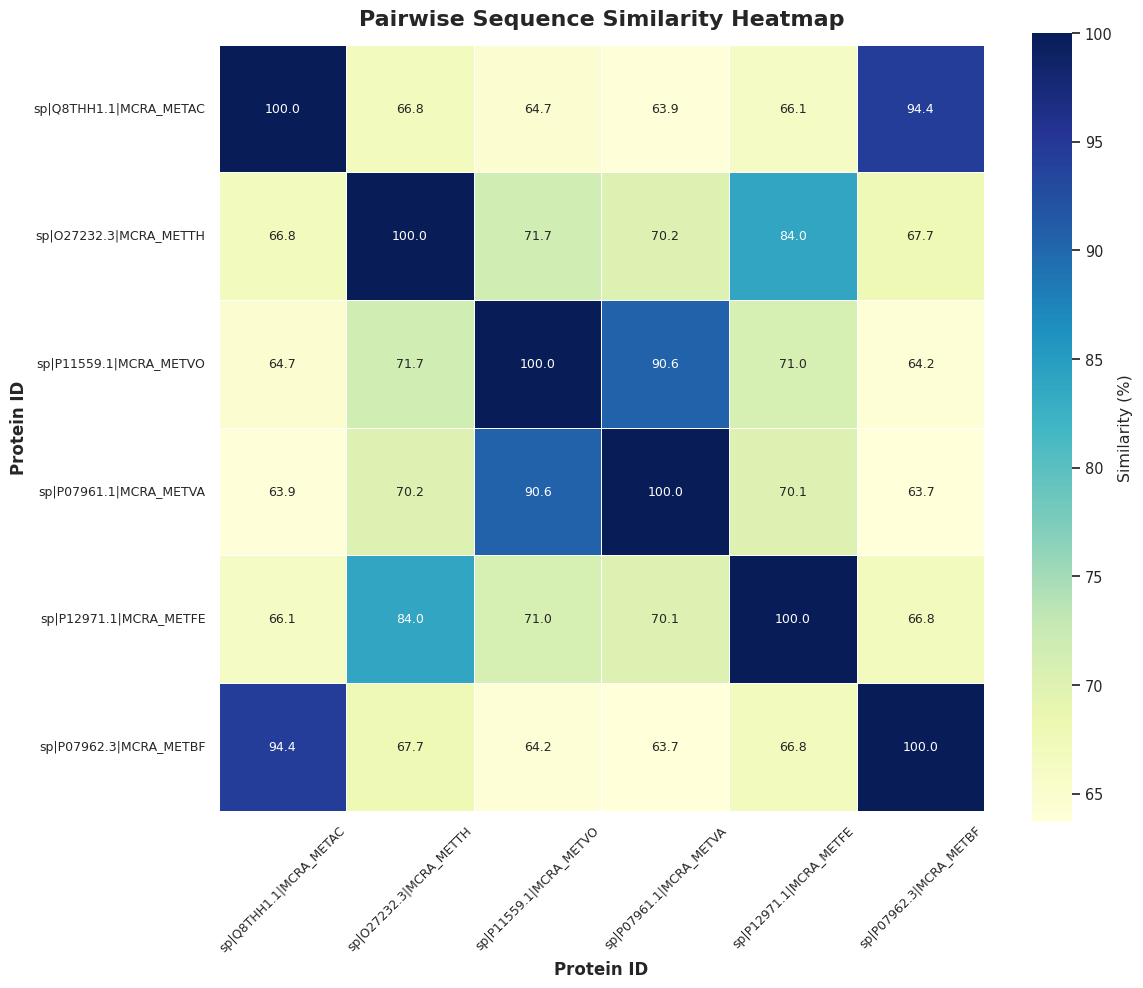

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# optional: make style nicer
sns.set_theme(style="white", font_scale=0.95)

# Create and store the heatmap figure for later export
heatmap_fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    similarity_df,
    annot=True,              # show numbers in cells
    fmt=".1f",               # 1 decimal place
    cmap="YlGnBu",           # prettier color map
    linewidths=0.5,          # lines between cells
    linecolor="white",
    square=True,             # make cells square
    cbar_kws={"label": "Similarity (%)"},
    annot_kws={"size": 9},
    ax=ax
)

ax.set_title("Pairwise Sequence Similarity Heatmap", fontsize=16, weight="bold", pad=14)
ax.set_xlabel("Protein ID", fontsize=12, weight="bold")
ax.set_ylabel("Protein ID", fontsize=12, weight="bold")

ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

### Build the physicochemical dendrogram

This cell clusters the proteins based on their physicochemical properties after standardizing the numeric values. The dendrogram helps show which sequences are most similar based on their calculated features rather than direct alignment.

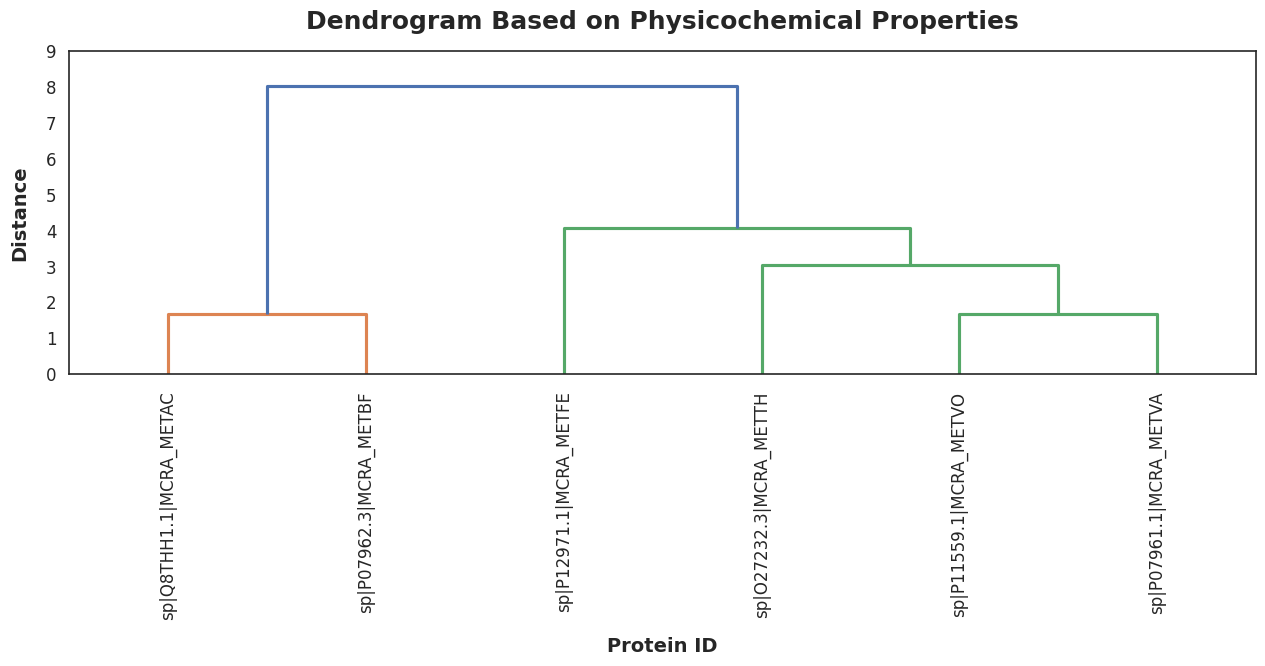

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select physicochemical columns
physchem_data = properties_df[[
    "Length",
    "Molecular_Weight",
    "Isoelectric_Point",
    "Extinction_Coefficient_Reduced",
    "Extinction_Coefficient_Oxidized",
    "Aromaticity",
    "Instability_Index",
    "Gravy"
]]

# Standardize values
scaler = StandardScaler()
scaled_physchem = scaler.fit_transform(physchem_data)

# Perform hierarchical clustering on the standardized values
linked_physchem = linkage(scaled_physchem, method="ward")

# Style
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

# Create and store the dendrogram figure for later export
physchem_dendrogram_fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

dendrogram(
    linked_physchem,
    labels=properties_df["ID"].tolist(),
    leaf_rotation=90,
    leaf_font_size=12,
    ax=ax
)

ax.set_title(
    "Dendrogram Based on Physicochemical Properties",
    fontsize=18,
    weight="bold",
    pad=16
)
ax.set_xlabel("Protein ID", fontsize=14, weight="semibold", labelpad=12)
ax.set_ylabel("Distance", fontsize=14, weight="semibold", labelpad=12)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

ax.grid(False)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12, length=6, width=1.2)

ymax = ax.get_ylim()[1]
ax.set_yticks(np.arange(0, ymax + 1, 1))

plt.tight_layout()
plt.show()

### Build the sequence dendrogram

This cell converts the sequence similarity matrix into a distance matrix and performs hierarchical clustering. The resulting dendrogram groups proteins according to how similar their sequences are.

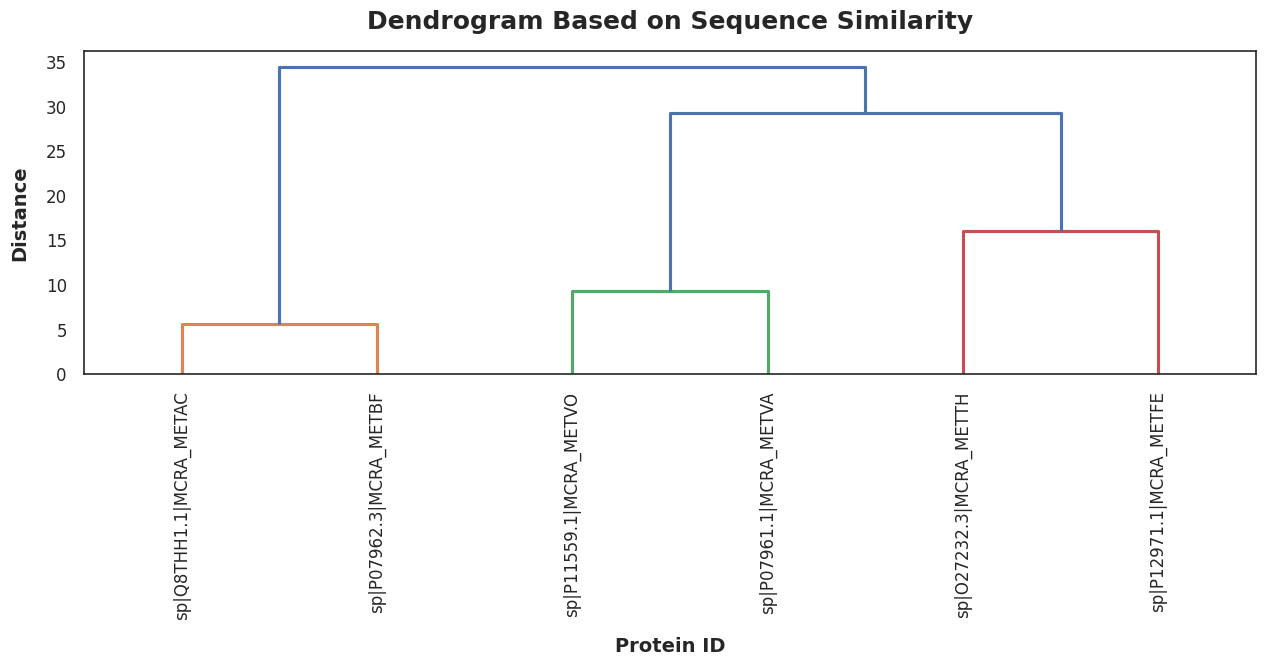

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Convert similarity matrix to distance matrix
distance_df = 100 - similarity_df.copy()

# Set diagonal to zero
np.fill_diagonal(distance_df.values, 0)

# Convert to condensed distance format
condensed_distance = squareform(distance_df.values)

# Perform hierarchical clustering using the sequence distance matrix
linked_seq = linkage(condensed_distance, method="average")

# Style
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

# Create and store the dendrogram figure for later export
seq_dendrogram_fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

dendrogram(
    linked_seq,
    labels=similarity_df.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=12,
    ax=ax
)

# Titles and labels
ax.set_title(
    "Dendrogram Based on Sequence Similarity",
    fontsize=18,
    weight="bold",
    pad=16
)
ax.set_xlabel("Protein ID", fontsize=14, weight="semibold", labelpad=12)
ax.set_ylabel("Distance", fontsize=14, weight="semibold", labelpad=12)

# Keep full box around plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Remove grid
ax.grid(False)

# Tick styling
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()

### Build the combined dendrogram

This cell combines two types of information: physicochemical distance and sequence distance. By averaging both standardized distance matrices, it creates a clustering result that reflects both biochemical features and sequence similarity.

Using these physicochemical columns:
['Length', 'Molecular_Weight', 'Isoelectric_Point', 'Extinction_Coefficient_Reduced', 'Extinction_Coefficient_Oxidized', 'Aromaticity', 'Instability_Index', 'Gravy']


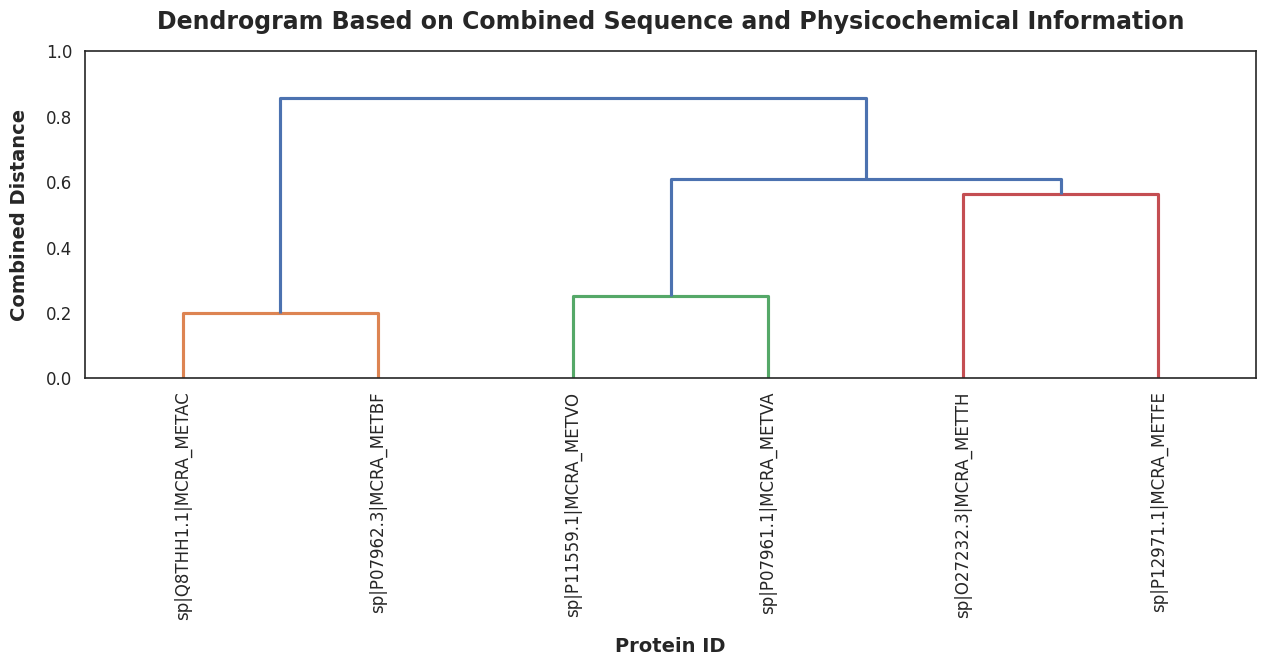

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Define the physicochemical properties you want
wanted_physchem_cols = [
    "Length",
    "Molecular_Weight",
    "Isoelectric_Point",
    "Net_Charge_pH_7",
    "Extinction_Coefficient_Reduced",
    "Extinction_Coefficient_Oxidized",
    "Aromaticity",
    "Instability_Index",
    "Gravy"
]

# 2. Keep only the columns that actually exist in properties_df
available_physchem_cols = [col for col in wanted_physchem_cols if col in properties_df.columns]

# Optional check
print("Using these physicochemical columns:")
print(available_physchem_cols)

if len(available_physchem_cols) == 0:
    raise ValueError("No valid physicochemical columns were found in properties_df.")

# 3. Select numeric physicochemical properties
physchem_data = properties_df[available_physchem_cols].copy()

# 4. Make sure all selected columns are numeric
physchem_data = physchem_data.apply(pd.to_numeric, errors="coerce")

# 5. Drop rows with missing values in selected columns
valid_mask = physchem_data.notna().all(axis=1)
physchem_data = physchem_data.loc[valid_mask].copy()

# Match IDs to the same filtered rows
filtered_ids = properties_df.loc[valid_mask, "ID"].tolist()

# 6. Standardize physicochemical data
scaler = StandardScaler()
scaled_physchem = scaler.fit_transform(physchem_data)

# 7. Compute physicochemical distance matrix
physchem_dist = squareform(pdist(scaled_physchem, metric="euclidean"))

# 8. Match sequence similarity matrix to the same filtered proteins
similarity_filtered = similarity_df.loc[filtered_ids, filtered_ids]

# 9. Compute sequence distance matrix
seq_dist = 100 - similarity_filtered.values
np.fill_diagonal(seq_dist, 0)

# 10. Standardize both distance matrices so one does not dominate
physchem_dist_scaled = physchem_dist / physchem_dist.max() if physchem_dist.max() != 0 else physchem_dist
seq_dist_scaled = seq_dist / seq_dist.max() if seq_dist.max() != 0 else seq_dist

# 11. Combine both standardized distance matrices with equal weight
combined_dist = (physchem_dist_scaled + seq_dist_scaled) / 2

# 12. Convert to condensed form
combined_condensed = squareform(combined_dist)

# 13. Cluster
linked_combined = linkage(combined_condensed, method="average")

# 14. Style
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

# Create and store the combined dendrogram figure for later export
combined_dendrogram_fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

dendrogram(
    linked_combined,
    labels=filtered_ids,
    leaf_rotation=90,
    leaf_font_size=12,
    ax=ax
)

ax.set_title(
    "Dendrogram Based on Combined Sequence and Physicochemical Information",
    fontsize=17,
    weight="bold",
    pad=16
)
ax.set_xlabel("Protein ID", fontsize=14, weight="semibold", labelpad=12)
ax.set_ylabel("Combined Distance", fontsize=14, weight="semibold", labelpad=12)

# Box around plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.tick_params(axis="y", which="major", length=6, width=1.2, direction="out", labelsize=12)
ax.tick_params(axis="x", which="major", length=6, width=1.2, direction="out", labelsize=12)

# Optional: clearer y tick spacing
ymax = ax.get_ylim()[1]
ax.set_yticks(np.arange(0, ymax + 0.2, 0.2))

ax.grid(False)

plt.tight_layout()
plt.show()

### Export results to a ZIP file

This cell saves the main outputs of the notebook into an `output` folder, including the two tables, the figures, and the input FASTA file. It then packages everything into a ZIP file so the results are easy to download and keep together.

In [ ]:
import os
import shutil
import zipfile
from Bio import SeqIO

# Ask the user whether to save all outputs into a ZIP file
make_output = input("Do you want to export the tables, figures, and input FASTA as a ZIP file? (yes/no): ").strip().lower()

if make_output in ["yes", "y"]:

    # Check that the required tables and sequence records already exist

    if "properties_df" not in globals():
        raise NameError("properties_df was not found. Run the earlier cells first.")

    if "input_records" not in globals():
        raise NameError("input_records was not found. Run the input cell first.")

    # Create output folder
    output_folder = os.path.join(os.getcwd(), "output")
    os.makedirs(output_folder, exist_ok=True)

    # -----------------------------
    # Table 1: physicochemical properties CSV
    # -----------------------------
    physchem_table = properties_df.copy()

    cols_to_remove = [
        col for col in [
            "Sequence",
            "sequence",
            "AA_Composition_Count",
            "AA_Composition_Percent"
        ]
        if col in physchem_table.columns
    ]

    if cols_to_remove:
        physchem_table = physchem_table.drop(columns=cols_to_remove)

    physchem_csv_path = os.path.join(output_folder, "physicochemical_properties.csv")
    physchem_table.to_csv(physchem_csv_path, index=False)

    # -----------------------------
    # Table 2: amino acid composition CSV
    # -----------------------------
    aa_cols = ["ID", "AA_Composition_Count", "AA_Composition_Percent"]
    existing_aa_cols = [col for col in aa_cols if col in properties_df.columns]

    if len(existing_aa_cols) < 3:
        raise ValueError("Could not find the amino acid composition columns inside properties_df.")

    aa_table = properties_df[existing_aa_cols].copy()
    aa_csv_path = os.path.join(output_folder, "amino_acid_composition.csv")
    aa_table.to_csv(aa_csv_path, index=False)

    # -----------------------------
    # Save input FASTA
    # -----------------------------
    fasta_path = os.path.join(output_folder, "input.fasta")
    SeqIO.write(input_records, fasta_path, "fasta")

    # -----------------------------
    # Save figure images
    # -----------------------------
    figure_map = [
        ("pairwise_sequence_similarity_heatmap.png", heatmap_fig),
        ("sequence_dendrogram.png", seq_dendrogram_fig),
        ("physicochemical_properties_dendrogram.png", physchem_dendrogram_fig),
        ("combined_dendrogram.png", combined_dendrogram_fig)
    ]

    # Save each stored figure as an image file
    for filename, figure_obj in figure_map:
        if figure_obj is not None:
            figure_path = os.path.join(output_folder, filename)
            figure_obj.savefig(figure_path, dpi=300, bbox_inches="tight")
            print(f"Saved figure: {filename}")

    # -----------------------------
    # Create ZIP file
    # -----------------------------
    zip_path = os.path.join(os.getcwd(), "output.zip")

    # Package the whole output folder into one ZIP file
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_folder):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, os.getcwd())
                zipf.write(full_path, arcname)

    print(f"\nAll files were saved in:\n{output_folder}")
    print(f"ZIP file created at:\n{zip_path}")

else:
    print("Export skipped.")

Do you want to export the tables, figures, and input FASTA as a ZIP file? (yes/no): yes
Saved figure: pairwise_sequence_similarity_heatmap.png
Saved figure: sequence_dendrogram.png
Saved figure: physicochemical_properties_dendrogram.png
Saved figure: combined_dendrogram.png

All files were saved in:
/content/output
ZIP file created at:
/content/output.zip
